# Task 2 - Exploratory Data Analysis (EDA)
**Project:** Customer Churn Analysis and Prediction &nbsp;|&nbsp; **Organisation:** Saiket Systems - Data Analysis Internship
**Task:** Task 2 of 4 &nbsp;|&nbsp; **Prepared by:** [Your Name] &nbsp;|&nbsp; **Date:** October 2026
**Dataset:** Telco Customer Churn (7,043 customers, 21 columns)

**Objective.** Measure the overall churn rate, explore the customer base by demographics and tenure, and investigate how churn relates to contract type and payment method.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
SEED = 42
PAL = {"No": "#4C78A8", "Yes": "#E45756"}

# Locate the project root whether this notebook sits in /notebooks or in the root folder
HERE = Path.cwd()
ROOT = next((p for p in [HERE, HERE.parent] if (p / "data" / "raw").exists()), HERE)
RAW = ROOT / "data" / "raw" / "Telco_Customer_Churn_Dataset_.csv"
PROCESSED = ROOT / "data" / "processed"; PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES = ROOT / "outputs" / "figures"; FIGURES.mkdir(parents=True, exist_ok=True)
TABLES = ROOT / "outputs" / "tables"; TABLES.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.savefig(FIGURES / name, dpi=150, bbox_inches="tight")

print("Project root:", ROOT)

Project root: /home/claude/telco-churn-project


In [2]:
CLEAN = PROCESSED / "telco_churn_cleaned.csv"
assert CLEAN.exists(), "Cleaned data not found - run Notebook 01 (data cleaning) first."
df = pd.read_csv(CLEAN)
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
print("Loaded cleaned data:", df.shape)

Loaded cleaned data: (7043, 22)


In [3]:
from scipy.stats import chi2_contingency

## 1. Overall churn rate

Overall churn rate: 26.54%  (1,869 of 7,043 customers)


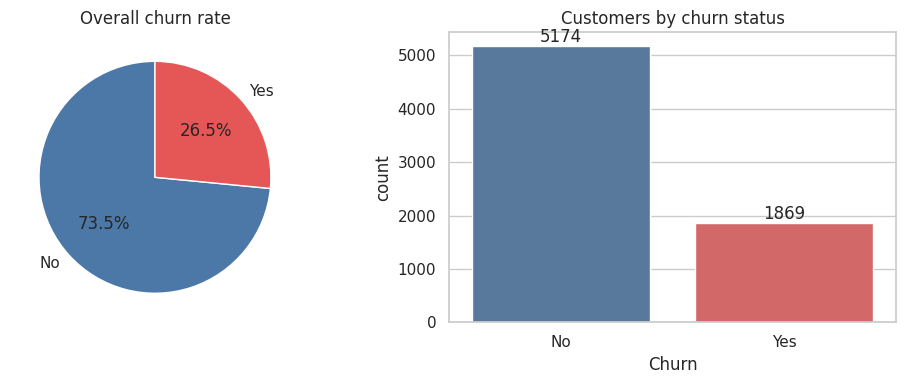

In [4]:
rate = df.ChurnFlag.mean() * 100
print(f"Overall churn rate: {rate:.2f}%  ({df.ChurnFlag.sum():,} of {len(df):,} customers)")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
counts = df.Churn.value_counts()
ax[0].pie(counts, labels=counts.index, autopct="%1.1f%%", colors=[PAL[i] for i in counts.index], startangle=90)
ax[0].set_title("Overall churn rate")
sns.countplot(data=df, x="Churn", hue="Churn", palette=PAL, legend=False, ax=ax[1])
for p in ax[1].patches:
    ax[1].annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
ax[1].set_title("Customers by churn status")
plt.tight_layout(); savefig("eda_01_overall_churn.png"); plt.show()

**Finding.** 26.5% of customers (1,869 of 7,043) have churned: roughly 1 in 4. The classes are imbalanced (about 73/27), which matters later when judging model accuracy.

## 2. Customer distribution by demographics

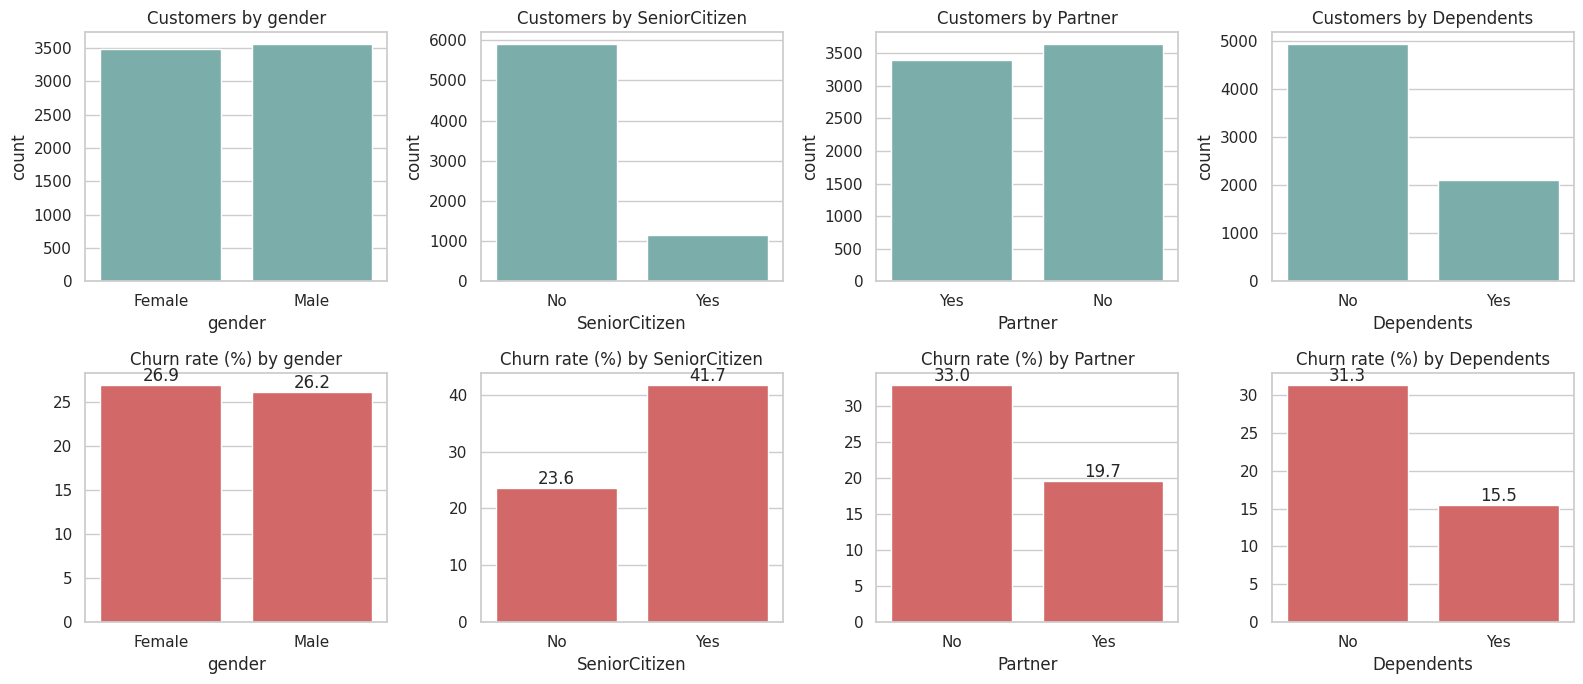

customers  churn_pct
gender        Female       3488       26.9
              Male         3555       26.2
SeniorCitizen No           5901       23.6
              Yes          1142       41.7
Partner       No           3641       33.0
              Yes          3402       19.7
Dependents    No           4933       31.3
              Yes          2110       15.5

In [5]:
DEMO = ["gender", "SeniorCitizen", "Partner", "Dependents"]
fig, axes = plt.subplots(2, len(DEMO), figsize=(4 * len(DEMO), 7))
for i, c in enumerate(DEMO):
    sns.countplot(data=df, x=c, color="#72B7B2", ax=axes[0, i]); axes[0, i].set_title(f"Customers by {c}")
    r = df.groupby(c).ChurnFlag.mean() * 100
    sns.barplot(x=r.index, y=r.values, color="#E45756", ax=axes[1, i]); axes[1, i].set_title(f"Churn rate (%) by {c}")
    for p in axes[1, i].patches:
        axes[1, i].annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
plt.tight_layout(); savefig("eda_02_demographics.png"); plt.show()

demo_tbl = pd.concat({c: df.groupby(c).agg(customers=("ChurnFlag", "size"), churn_pct=("ChurnFlag", lambda s: round(s.mean()*100, 1))) for c in DEMO})
demo_tbl

**Findings**
* **Gender has no effect** on churn (female 26.9% vs male 26.2%).
* **Senior citizens churn far more** (41.7% vs 23.6%), although they are a minority of the base.
* Customers **with a partner** (19.7% vs 33.0%) or **with dependents** (15.5% vs 31.3%) are much less likely to leave. Household ties appear to make customers stickier.

## 3. Tenure distribution

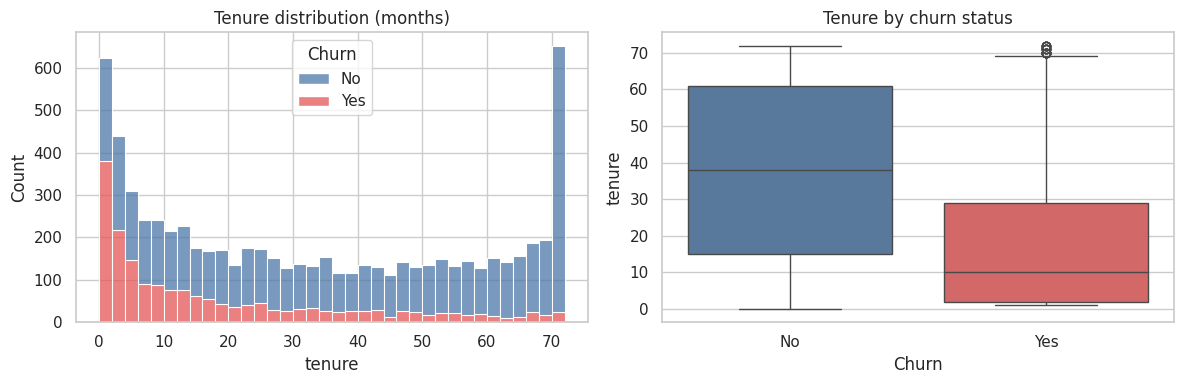

        count  mean   std  min   25%   50%   75%   max
Churn                                                 
No     5174.0  37.6  24.1  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  18.0  19.5  1.0   2.0  10.0  29.0  72.0

Churn rate tenure <= 12 months: 47.4% | after: 17.1%


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=36, palette=PAL, multiple="stack", ax=ax[0])
ax[0].set_title("Tenure distribution (months)")
sns.boxplot(data=df, x="Churn", y="tenure", hue="Churn", palette=PAL, legend=False, ax=ax[1])
ax[1].set_title("Tenure by churn status")
plt.tight_layout(); savefig("eda_03_tenure.png"); plt.show()

print(df.groupby("Churn").tenure.describe().round(1))
CUTOFF = 12
print(f"\nChurn rate tenure <= {CUTOFF} months: {df[df.tenure <= CUTOFF].ChurnFlag.mean():.1%} | after: {df[df.tenure > CUTOFF].ChurnFlag.mean():.1%}")

**Findings.** The tenure histogram is U-shaped: many customers are brand new and many have stayed the full 72 months. Churned customers have a median tenure of only **10 months**, against **38 months** for retained customers. Churn is **47.4%** in the first year and **17.1%** afterwards, so the first 12 months are the critical window.

## 4. Churn by contract type and payment method

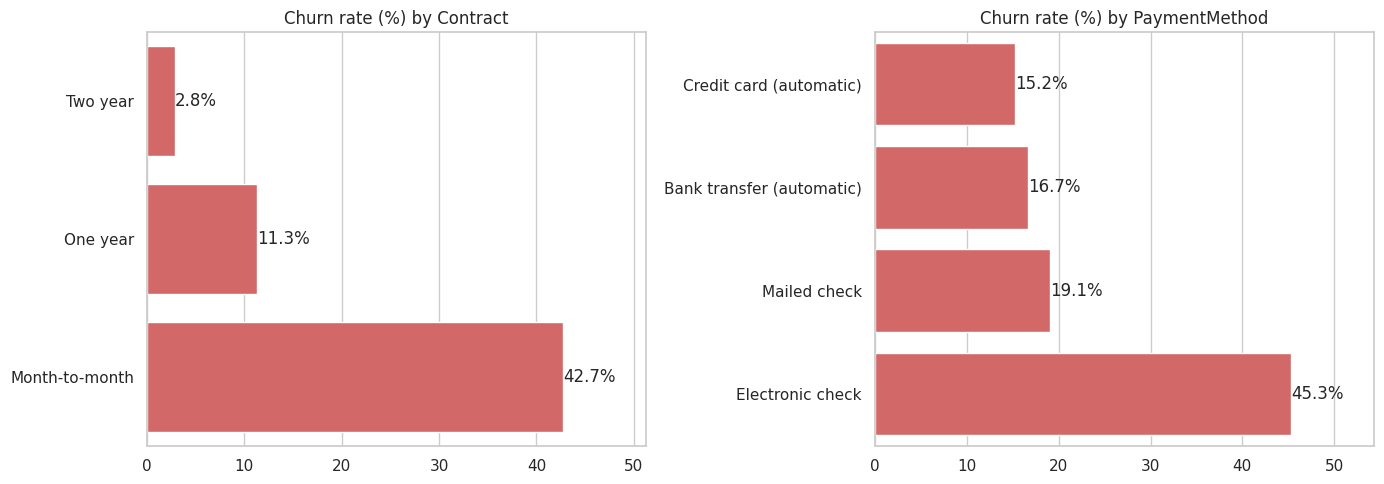

,customers,churned,churn_pct
Contract,,,
Month-to-month,3875,1655,42.7
One year,1473,166,11.3
Two year,1695,48,2.8


,customers,churned,churn_pct
PaymentMethod,,,
Electronic check,2365,1071,45.3
Mailed check,1612,308,19.1
Bank transfer (automatic),1544,258,16.7
Credit card (automatic),1522,232,15.2


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, c in zip(ax, ["Contract", "PaymentMethod"]):
    r = df.groupby(c).ChurnFlag.mean().mul(100).sort_values()
    sns.barplot(x=r.values, y=r.index, color="#E45756", ax=a)
    a.set_title(f"Churn rate (%) by {c}"); a.set_ylabel(""); a.set_xlim(0, r.max() * 1.2)
    for p in a.patches:
        a.annotate(f"{p.get_width():.1f}%", (p.get_width(), p.get_y() + p.get_height() / 2), va="center", ha="left")
plt.tight_layout(); savefig("eda_04_contract_payment.png"); plt.show()

for c in ["Contract", "PaymentMethod"]:
    display(df.groupby(c).agg(customers=("ChurnFlag", "size"), churned=("ChurnFlag", "sum"),
                              churn_pct=("ChurnFlag", lambda s: round(s.mean()*100, 1))).sort_values("churn_pct", ascending=False))

**Findings**
* **Contract is the strongest relationship in the data.** Month-to-month customers churn at 42.7%, one-year at 11.3% and two-year at only 2.8%.
* **Electronic-check payers churn at 45.3%**, about three times the rate of customers on automatic bank transfer (16.7%) or credit card (15.2%). They are also the largest payment group (2,365 customers).
* Caution: this is association, not proof of cause. Electronic check may be a marker of less committed customers rather than a cause of leaving.

## 5. Other service factors

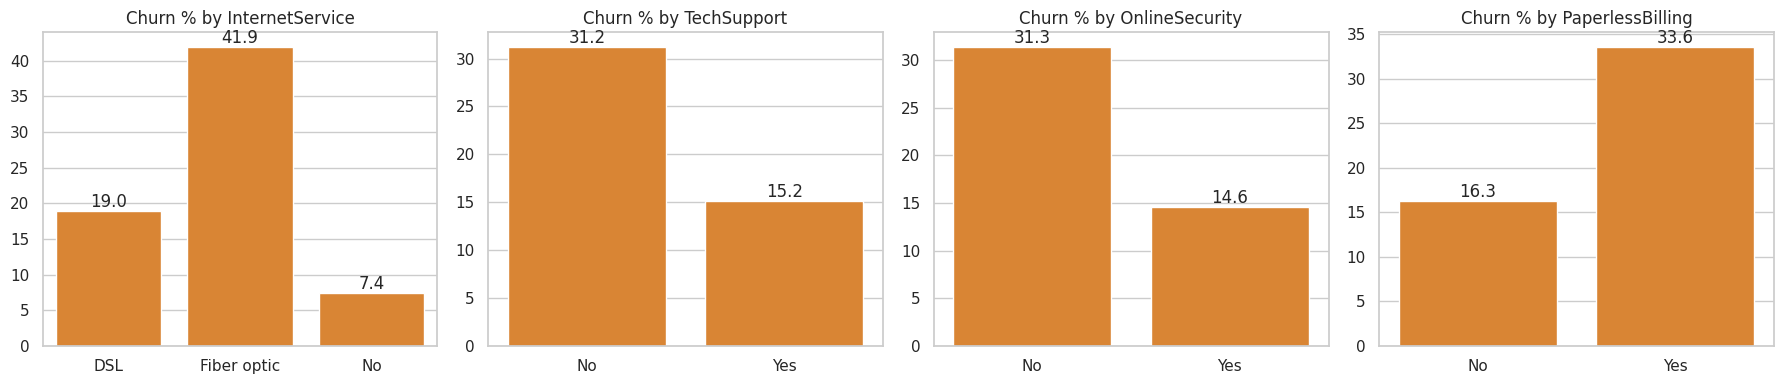

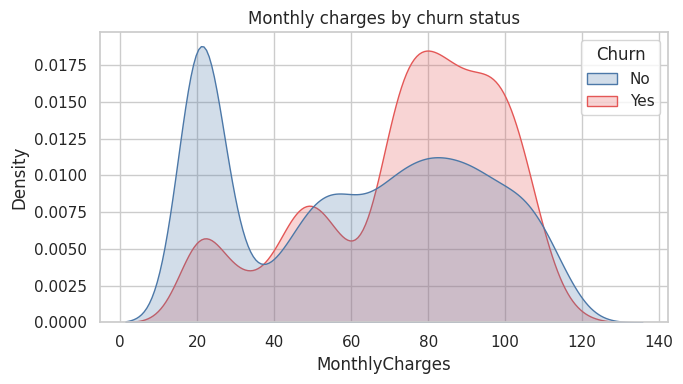

Average monthly charge - churned: $74.4 | retained: $61.3


In [8]:
factors = ["InternetService", "TechSupport", "OnlineSecurity", "PaperlessBilling"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for a, c in zip(axes, factors):
    r = df.groupby(c).ChurnFlag.mean().mul(100)
    sns.barplot(x=r.index, y=r.values, color="#F58518", ax=a); a.set_title(f"Churn % by {c}"); a.set_xlabel("")
    for p in a.patches: a.annotate(f"{p.get_height():.1f}", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.tight_layout(); savefig("eda_05_service_factors.png"); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", palette=PAL, fill=True, common_norm=False, ax=ax)
ax.set_title("Monthly charges by churn status"); plt.tight_layout(); savefig("eda_06_monthly_charges.png"); plt.show()
print("Average monthly charge - churned: $%.1f | retained: $%.1f" % (df[df.Churn=="Yes"].MonthlyCharges.mean(), df[df.Churn=="No"].MonthlyCharges.mean()))

**Findings**
* **Fiber-optic customers churn at 41.9%**, versus 19.0% for DSL and 7.4% for customers with no internet service.
* Customers **without tech support (31.2% vs 15.2%)** or **without online security (31.3% vs 14.6%)** churn about twice as often.
* **Churners pay more:** average monthly charge is $74.40 for churned customers versus $61.30 for retained ones. Fiber plans are likely driving this.

## 6. Are these relationships statistically real? (chi-square test)

In [9]:
rows = []
for c in ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "InternetService",
          "Contract", "PaymentMethod", "PaperlessBilling", "OnlineSecurity", "TechSupport"]:
    chi2, p, _, _ = chi2_contingency(pd.crosstab(df[c], df.Churn))
    n_ = len(df); k = min(pd.crosstab(df[c], df.Churn).shape) - 1
    rows.append({"feature": c, "chi2": round(chi2, 1), "p_value": p, "cramers_v": round((chi2 / (n_ * k)) ** 0.5, 3),
                 "significant (p<0.05)": p < 0.05})
chi_tbl = pd.DataFrame(rows).sort_values("chi2", ascending=False).reset_index(drop=True)
chi_tbl.to_csv(TABLES / "eda_chi_square.csv", index=False)
chi_tbl

,feature,chi2,p_value,cramers_v,significant (p<0.05)
0,Contract,1184.6,5.863038e-258,0.410,True
1,InternetService,732.3,9.571788e-160,0.322,True
2,PaymentMethod,648.1,3.682355e-140,0.303,True
3,PaperlessBilling,258.3,4.073355e-58,0.191,True
4,OnlineSecurity,205.6,1.232098e-46,0.171,True
5,TechSupport,190.2,2.923567e-43,0.164,True
6,Dependents,189.1,4.924922e-43,0.164,True
7,SeniorCitizen,159.4,1.510067e-36,0.150,True
8,Partner,158.7,2.139911e-36,0.150,True
9,PhoneService,0.9,3.387825e-01,0.011,False


A chi-square test of independence asks whether churn depends on a feature or whether the pattern could be chance. With 7,043 customers, even small differences can be "significant", so **Cramer's V** (effect size, 0 to 1) is shown too. Contract, internet service and payment method have the largest effect sizes. Gender and phone service show no significant relationship (p = 0.49 and 0.34).

## Summary of Task 2
| Question | Answer |
|---|---|
| Overall churn rate | **26.5%** (1,869 of 7,043) |
| Demographics | Gender irrelevant; seniors (41.7%), customers without partner (33.0%) or dependents (31.3%) churn more |
| Tenure | Churners: median 10 months vs 38 for retained. Churn is 47.4% in year 1 vs 17.1% later |
| Contract | Month-to-month 42.7% / one-year 11.3% / two-year 2.8% |
| Payment method | Electronic check 45.3% vs 15-19% for all others |
| Other drivers | Fiber optic 41.9%; no tech support 31.2%; no online security 31.3% |

**Implication.** Churn is concentrated in new, month-to-month, fiber-optic customers paying by electronic check without support or security add-ons. This group is analysed further in Notebook 03.